In [6]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=10)

In [7]:
import matplotlib.pyplot as plt

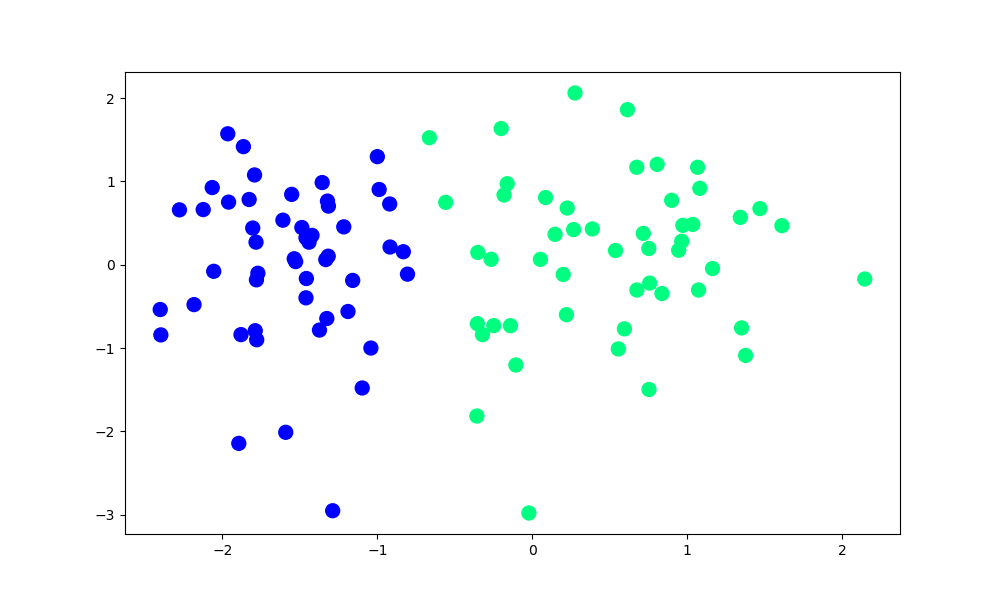

In [8]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [9]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]
        

In [10]:

def step(z):
    return 1 if z>0 else 0

In [11]:

intercept_,coef_ = perceptron(X,y)

In [12]:
print(coef_)
print(intercept_)

[1.32179438 0.19359034]
0.9


In [13]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [14]:

x_input = np.linspace(-3,3,100)
y_input = m*x_input + b

(-3.0, 2.0)

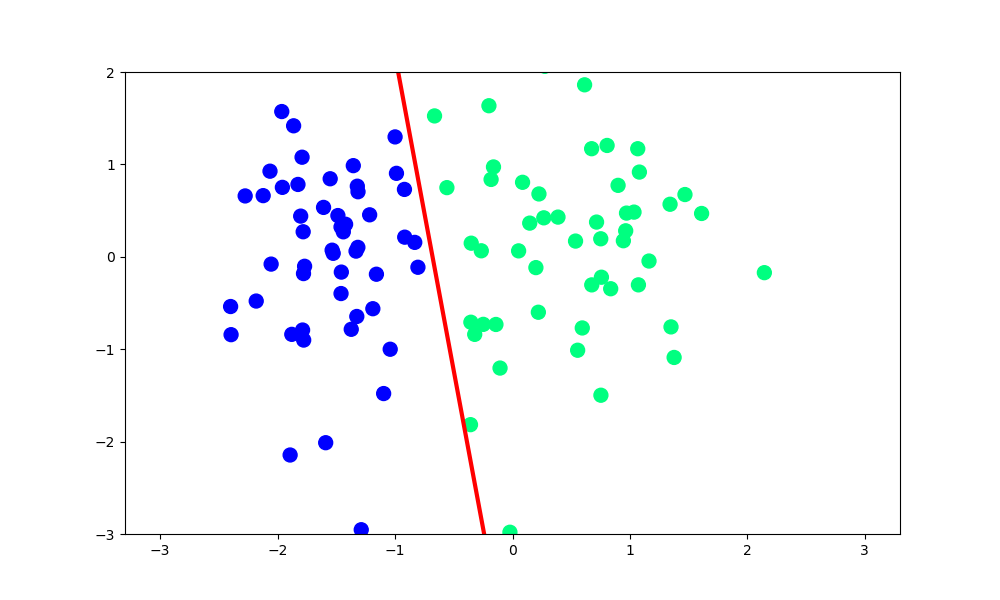

In [15]:

plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [16]:
def perceptron(X,y):
    m=[]
    b=[]
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1 
    for i in range(200):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]
        m.append(-weights[1]/weights[2])
        b.append(-weights[0]/weights[2])
    return m,b

In [17]:
m,b=perceptron(X,y)

In [20]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation


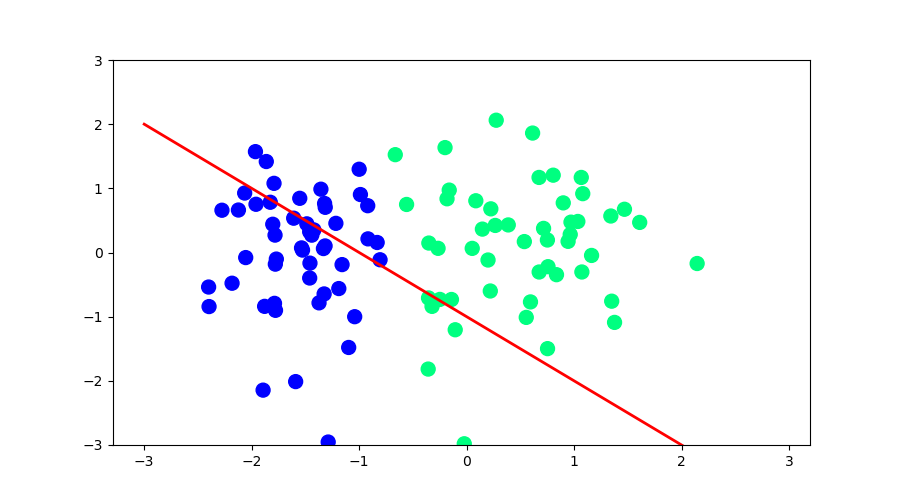

In [19]:
   # <- important for JupyterLab

fig, ax = plt.subplots(figsize=(9, 5))
x_i = np.arange(-3, 3, 0.1)
y_i = x_i * m[0] + b[0]

ax.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', s=100)
line, = ax.plot(x_i, y_i, 'r-', linewidth=2)
plt.ylim(-3, 3)

def update(i):
    label = f'epoch {i+1}'
    line.set_ydata(x_i * m[i] + b[i])
    ax.set_xlabel(label)
    return line,

anim = FuncAnimation(fig, update, frames=len(m), interval=100, repeat=True)
plt.show()
